In [25]:
import pandas as pd              # pandas is used to handle tabular data (like Excel sheets)
import numpy as np               # numpy is used for numerical operations and arrays
import matplotlib.pyplot as plt  # matplotlib is used for creating graphs and charts
import seaborn as sns            # seaborn is used to create cleaner and better-looking plots

plt.style.use('default')         # sets a simple and clean default style for all plots


In [26]:
df = pd.read_csv("/netflix_titles.csv")   # reads the Netflix CSV file from the given path and loads it into a DataFrame named df
df.head()                                 # displays the first 5 rows of the DataFrame to quickly verify the data is loaded correctly


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [27]:
df.info()        # shows a summary of the DataFrame: column names, data types, non-null counts, and memory usage
df.describe()    # generates statistical summary for numerical columns (count, mean, std, min, max, etc.)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [28]:
df.isnull().sum()    # checks for missing (NaN) values in each column and returns the total count per column


,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [29]:
df['director'].fillna("Unknown", inplace=True)          # replaces missing values in the 'director' column with the string "Unknown"
df['cast'].fillna("Not Available", inplace=True)        # replaces missing values in the 'cast' column with the string "Not Available"
df.dropna(subset=['country', 'rating'], inplace=True)   # removes rows where 'country' or 'rating' values are missing



/tmp/ipython-input-1715849598.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director'].fillna("Unknown", inplace=True)          # replaces missing values in the 'director' column with the string "Unknown"
/tmp/ipython-input-1715849598.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behav

In [30]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')  # converts 'date_added' column from text to datetime format; invalid dates become NaT instead of causing errors
df['year_added'] = df['date_added'].dt.year                          # extracts only the year from the datetime column and stores it in a new column 'year_added'


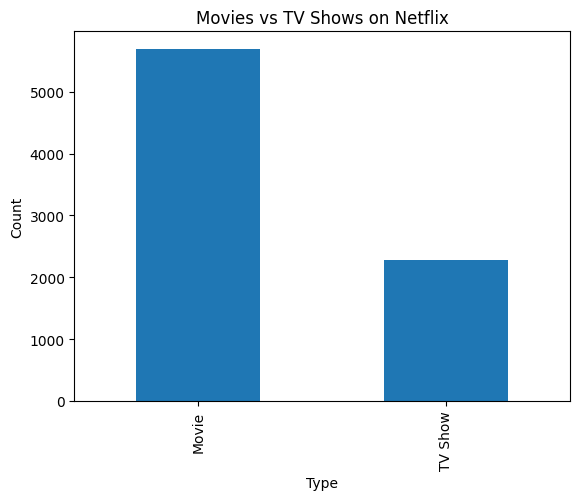

In [31]:
df['type'].value_counts().plot(kind='bar')   # counts the number of Movies and TV Shows and plots the result as a bar chart
plt.title("Movies vs TV Shows on Netflix")   # sets the title of the bar chart
plt.xlabel("Type")                           # labels the x-axis to show content type (Movie or TV Show)
plt.ylabel("Count")                          # labels the y-axis to show the total number of titles
plt.show()                                   # displays the plotted chart


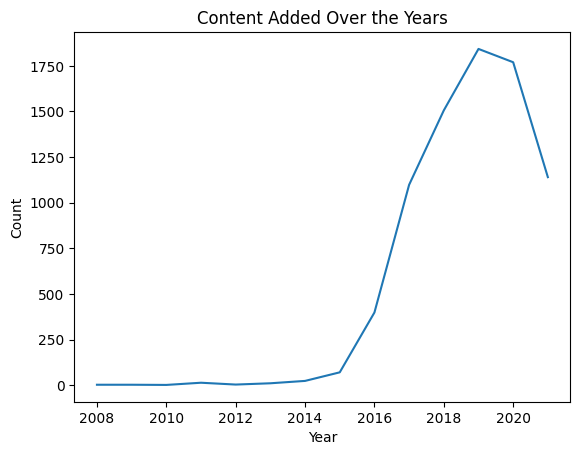

In [32]:
df['year_added'].value_counts().sort_index().plot(kind='line')  # counts titles added each year, sorts years in ascending order, and plots a line chart to show trend over time
plt.title("Content Added Over the Years")                       # sets the title of the line chart
plt.xlabel("Year")                                              # labels the x-axis as Year
plt.ylabel("Count")                                             # labels the y-axis as number of titles added
plt.show()                                                      # displays the plotted line chart


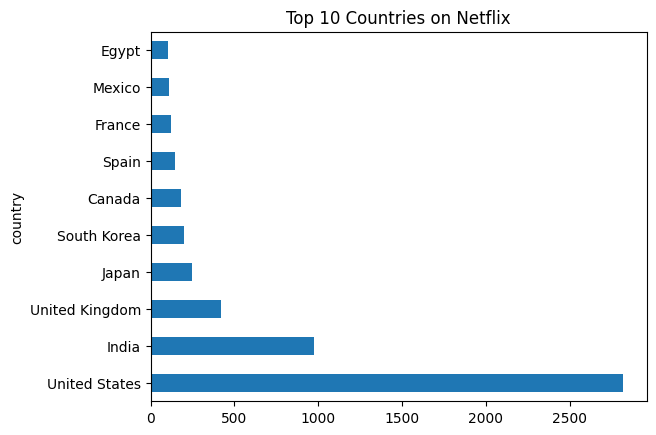

In [33]:
top_countries = df['country'].value_counts().head(10)   # counts the number of titles per country and selects the top 10 countries

top_countries.plot(kind='barh')                         # plots a horizontal bar chart for better readability of country names
plt.title("Top 10 Countries on Netflix")                # sets the title of the chart
plt.show()                                              # displays the plotted chart


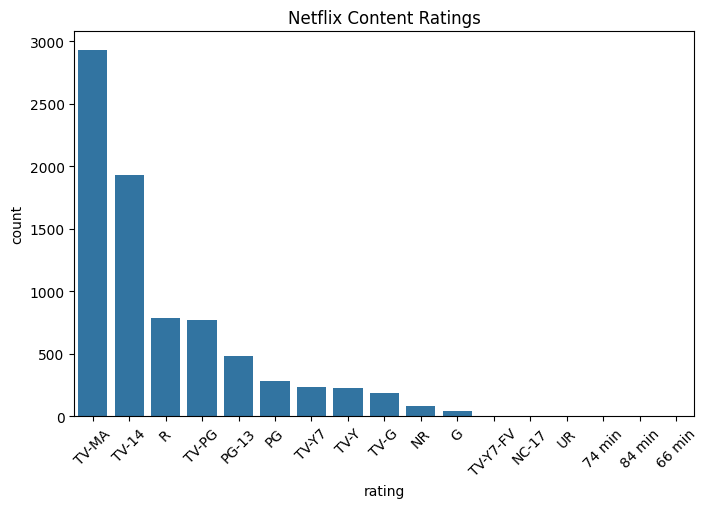

In [34]:
plt.figure(figsize=(8,5))                                                # creates a new figure and sets the size of the plot (width=8, height=5)

sns.countplot(data=df, x='rating', order=df['rating'].value_counts().index)  # creates a count plot showing number of titles for each rating, ordered by frequency

plt.xticks(rotation=45)                                                   # rotates x-axis labels by 45 degrees to avoid overlap
plt.title("Netflix Content Ratings")                                      # sets the title of the chart
plt.show()                                                                # displays the plotted chart


/tmp/ipython-input-744537489.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies['duration_num'] = pd.to_numeric(                         # creates a new column to store movie duration as a number


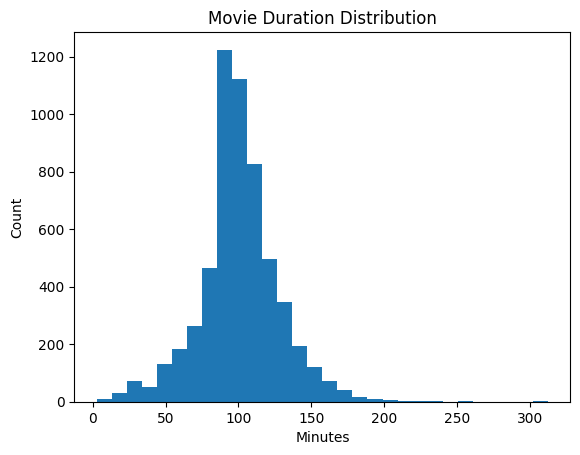

In [35]:
movies = df[df['type'] == 'Movie']                              # filters the DataFrame to keep only rows where the content type is 'Movie'

movies['duration_num'] = pd.to_numeric(                         # creates a new column to store movie duration as a number
    movies['duration'].str.replace(" min", "", regex=False),    # removes the text " min" from duration values (e.g., "90 min" → "90")
    errors='coerce'                                              # converts invalid or missing values to NaN instead of throwing an error
)

movies = movies.dropna(subset=['duration_num'])                 # removes rows where movie duration could not be converted to a number

plt.hist(movies['duration_num'], bins=30)                       # creates a histogram showing the distribution of movie durations
plt.title("Movie Duration Distribution")                        # sets the title of the histogram
plt.xlabel("Minutes")                                           # labels the x-axis as movie duration in minutes
plt.ylabel("Count")                                             # labels the y-axis as number of movies
plt.show()                                                      # displays the plotted histogram


• Cleaned missing data
• Analyzed trends over time
• Found Movies dominate Netflix content
• USA & India are top contributors
